<a href="https://colab.research.google.com/github/DEESHA-AFK/T076-ARTIFICIAL-INTELLIGENCE-PRACTICAL/blob/main/T076_AI_PRAC_9_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic (1).csv


In [11]:
filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

print(data.head())
print(data.columns)

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Par

In [13]:
X = data[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]]
y = data["Survived"]

X = X.copy()
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
X["Age"] = X["Age"].fillna(X["Age"].mean())
X["Fare"] = X["Fare"].fillna(X["Fare"].mean())

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 1.0
Confusion Matrix:
[[50  0]
 [ 0 34]]


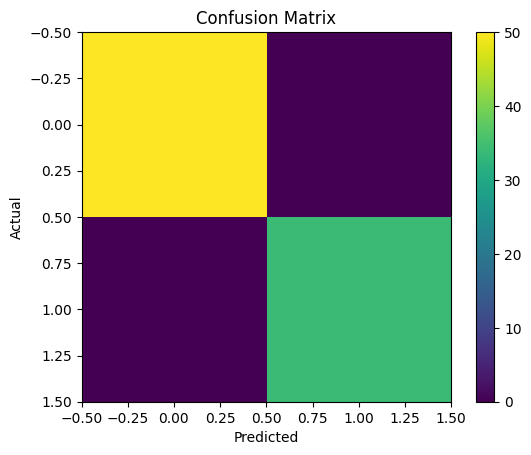

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Select features
X = data[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]]
y = data["Survived"]

# Convert Sex to numbers
X = X.copy()
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})

# Fill missing values
X["Age"] = X["Age"].fillna(X["Age"].mean())
X["Fare"] = X["Fare"].fillna(X["Fare"].mean())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feed Forward Neural Network
model = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000)

# Train using Backpropagation
model.fit(X_train, y_train)

# Test
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()
